<a href="https://colab.research.google.com/github/sarthak572/learning/blob/main/Predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Learning Probability Density Functions Using a Roll-Number-Parameterized Non-Linear Model and Maximum Likelihood Estimation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
!pip install opendatasets


In [7]:
import opendatasets as od

dataset_url = "https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data"
od.download(dataset_url)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sarthakbansal1152
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data


100%|██████████| 5.22M/5.22M [00:00<00:00, 811MB/s]

In [9]:
import pandas as pd

file_path = "/content/india-air-quality-data/data.csv"  # adjust if needed

try:
    df = pd.read_csv(file_path, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully")
print("Available columns:")
print(df.columns)


Dataset loaded successfully
Available columns:
Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')


/tmp/ipython-input-2288624697.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding="latin1")


In [10]:
# Auto-detect NO2 column safely
no2_col = [col for col in df.columns if "NO2" in col.upper()][0]
print("Using NO2 column:", no2_col)

x = df[no2_col].dropna().values

# Roll number
r = 102316063

# Roll-number-based parameters
a_r = 0.05 * (r % 7)
b_r = 0.3 * ((r % 5) + 1)

print("a_r =", a_r)
print("b_r =", b_r)


Using NO2 column: no2
a_r = 0.15000000000000002
b_r = 1.2


In [12]:


z = x + a_r * np.sin(b_r * x)

In [13]:

print("Original NO2 Statistics")
print("Mean:", np.mean(x))
print("Variance:", np.var(x))

print("\nTransformed z Statistics")
print("Mean:", np.mean(z))
print("Variance:", np.var(z))

Original NO2 Statistics
Mean: 25.809622897811263
Variance: 342.36339017375917

Transformed z Statistics
Mean: 25.806338519611327
Variance: 342.4681206372513


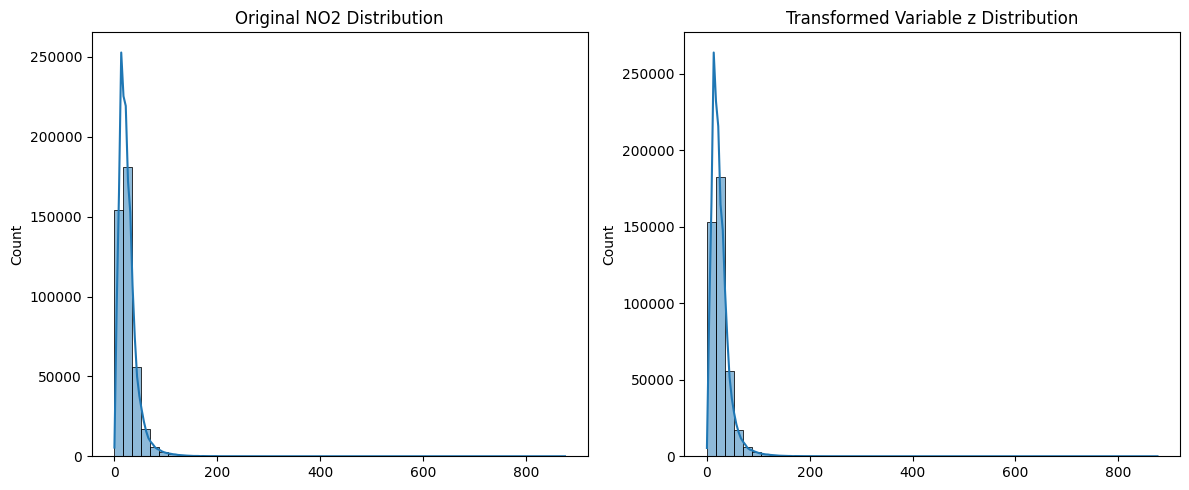

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(x, bins=50, kde=True)
plt.title("Original NO2 Distribution")

plt.subplot(1, 2, 2)
sns.histplot(z, bins=50, kde=True)
plt.title("Transformed Variable z Distribution")

plt.tight_layout()
plt.show()

In [15]:

# MLE estimates
mu_hat = np.mean(z)
variance_hat = np.mean((z - mu_hat) ** 2)
lambda_hat = 1 / (2 * variance_hat)
norm_const = np.sqrt(lambda_hat / np.pi)

print("Estimated Parameters:")
print("μ (mu) =", mu_hat)
print("λ (lambda) =", lambda_hat)
print("c =", norm_const)


Estimated Parameters:
μ (mu) = 25.806338519611327
λ (lambda) = 0.0014599899081690277
c = 0.02155757921239688


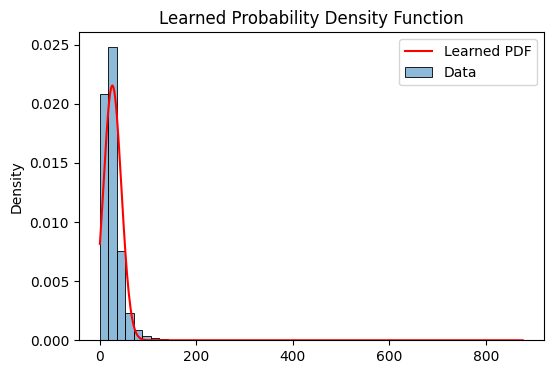

In [16]:
z_range = np.linspace(min(z), max(z), 500)
pdf = norm_const * np.exp(-lambda_hat * (z_range - mu_hat) ** 2)

plt.figure(figsize=(6, 4))
sns.histplot(z, bins=50, stat="density", alpha=0.5, label="Data")
plt.plot(z_range, pdf, 'r', label="Learned PDF")
plt.legend()
plt.title("Learned Probability Density Function")
plt.show()

# **Conclusion**
In this assignment, a roll-number-parameterized non-linear transformation was applied to NO₂ concentration data. The transformed variable was modeled using a Gaussian-type probability density function, and its parameters were estimated using Maximum Likelihood Estimation. The results demonstrate how statistical modeling and personalization can be combined to learn real-world data distributions effectively.